# Coffs Harbour — Sea State Comparison (Jan 2020)

This notebook combines five IMOS datasets to characterise the ocean state off
**Coffs Harbour (~30.3 °S, 153.1 °E)** around **January 2020**.  
The East Australian Current (EAC) reaches its narrowest, swiftest point here before separating from
the coast — making it a compelling site for multi-platform comparisons.

| # | Platform | Dataset | Variables | Format |
|---|----------|---------|-----------|--------|
| 1 | **HF Radar – currents** | `radar_CoffsHarbour_velocity_hourly_averaged_delayed_qc` | UCUR, VCUR | Zarr |
| 2 | **HF Radar – waves** | `radar_CoffsHarbour_wave_delayed_qc` | VAVH, WPPE | Zarr |
| 3 | **Satellite SST** | `satellite_ghrsst_l3s_1day_daynighttime_multi_sensor_australia` | sea_surface_temperature | Zarr |
| 4 | **Slocum glider (Yamba)** | `slocum_glider_delayed_qc` | TEMP, PSAL, CPHL | Parquet |
| 5 | **Argo floats** | `argo` | TEMP, PSAL, PRES | Parquet |

**Data-coverage notes:**
- The national wave buoy archive (`wave_buoy_realtime_nonqc`) only starts from Sep 2022 — the HF radar wave product is used instead.
- The `wind_speed` field listed in the GHRSST schema is **absent** from the live Zarr store and is not used.
- SST is stored in **Kelvin** in the Zarr store; all plots convert to °C.
- The nearest Slocum glider deployment is **Yamba20191108** (Nov 2019), which passed within **15 km** of Coffs Harbour and provides excellent subsurface context.

---
## 0 · Setup

In [1]:
import os, requests, importlib.util

open('setup.py', 'w').write(
    requests.get(
        'https://raw.githubusercontent.com/aodn/aodn_cloud_optimised/main/notebooks/setup.py'
    ).text
)
spec = importlib.util.spec_from_file_location('setup', 'setup.py')
setup = importlib.util.module_from_spec(spec)
spec.loader.exec_module(setup)
setup.install_requirements()
setup.load_dataquery()

✅ Virtual environment already exists, skipping creation.


Using Python 3.12.6 environment at: /home/lbesnard/github_repo/aodn_cloud_optimised/.venv
Resolved 201 packages in 836ms
Checked 201 packages in 1ms


✅ Local version 0.3.25 is up to date (remote: 0.3.18)


In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Rectangle

from DataQuery import GetAodn, plot_ts_diagram

warnings.filterwarnings('ignore')

# ── Shared constants ──────────────────────────────────────────────────────────
COF_LAT, COF_LON = -30.3, 153.1          # Coffs Harbour reference point

DATE_START = '2020-01-01'
DATE_END   = '2020-02-01'

# Wide bounding box for Parquet queries
LAT_MIN, LAT_MAX = -35.0, -27.0
LON_MIN, LON_MAX = 150.0, 158.0

# Region for maps and SST extraction
MAP_LAT = (-32.5, -28.0)
MAP_LON = (151.5, 156.0)

aodn = GetAodn()

/home/lbesnard/github_repo/aodn_cloud_optimised/notebooks/mcp_generated_notebooks/DataQuery.py:4679: UserWarning: registration of accessor <class 'DataQuery.AODNAccessor'> under name 'aodn' for type <class 'pandas.core.frame.DataFrame'> is overriding a preexisting attribute with the same name.
  @pd.api.extensions.register_dataframe_accessor("aodn")


---
## 1 · HF Radar — Surface Currents

The Coffs Harbour WERA HF radar measures hourly-averaged surface current vectors
(`UCUR` east, `VCUR` north) over a ~100 km × 100 km domain.

The grid point with the most valid data in January 2020 is used for timeseries extraction
(found automatically from data coverage).

In [3]:
%%time
ds_vel = aodn.get_dataset('radar_CoffsHarbour_velocity_hourly_averaged_delayed_qc.zarr')
ds_vel.get_temporal_extent()

CPU times: user 594 ms, sys: 44.6 ms, total: 639 ms
Wall time: 1.42 s


(Timestamp('2012-03-07 04:30:00'), Timestamp('2024-09-30 23:29:59.999996928'))

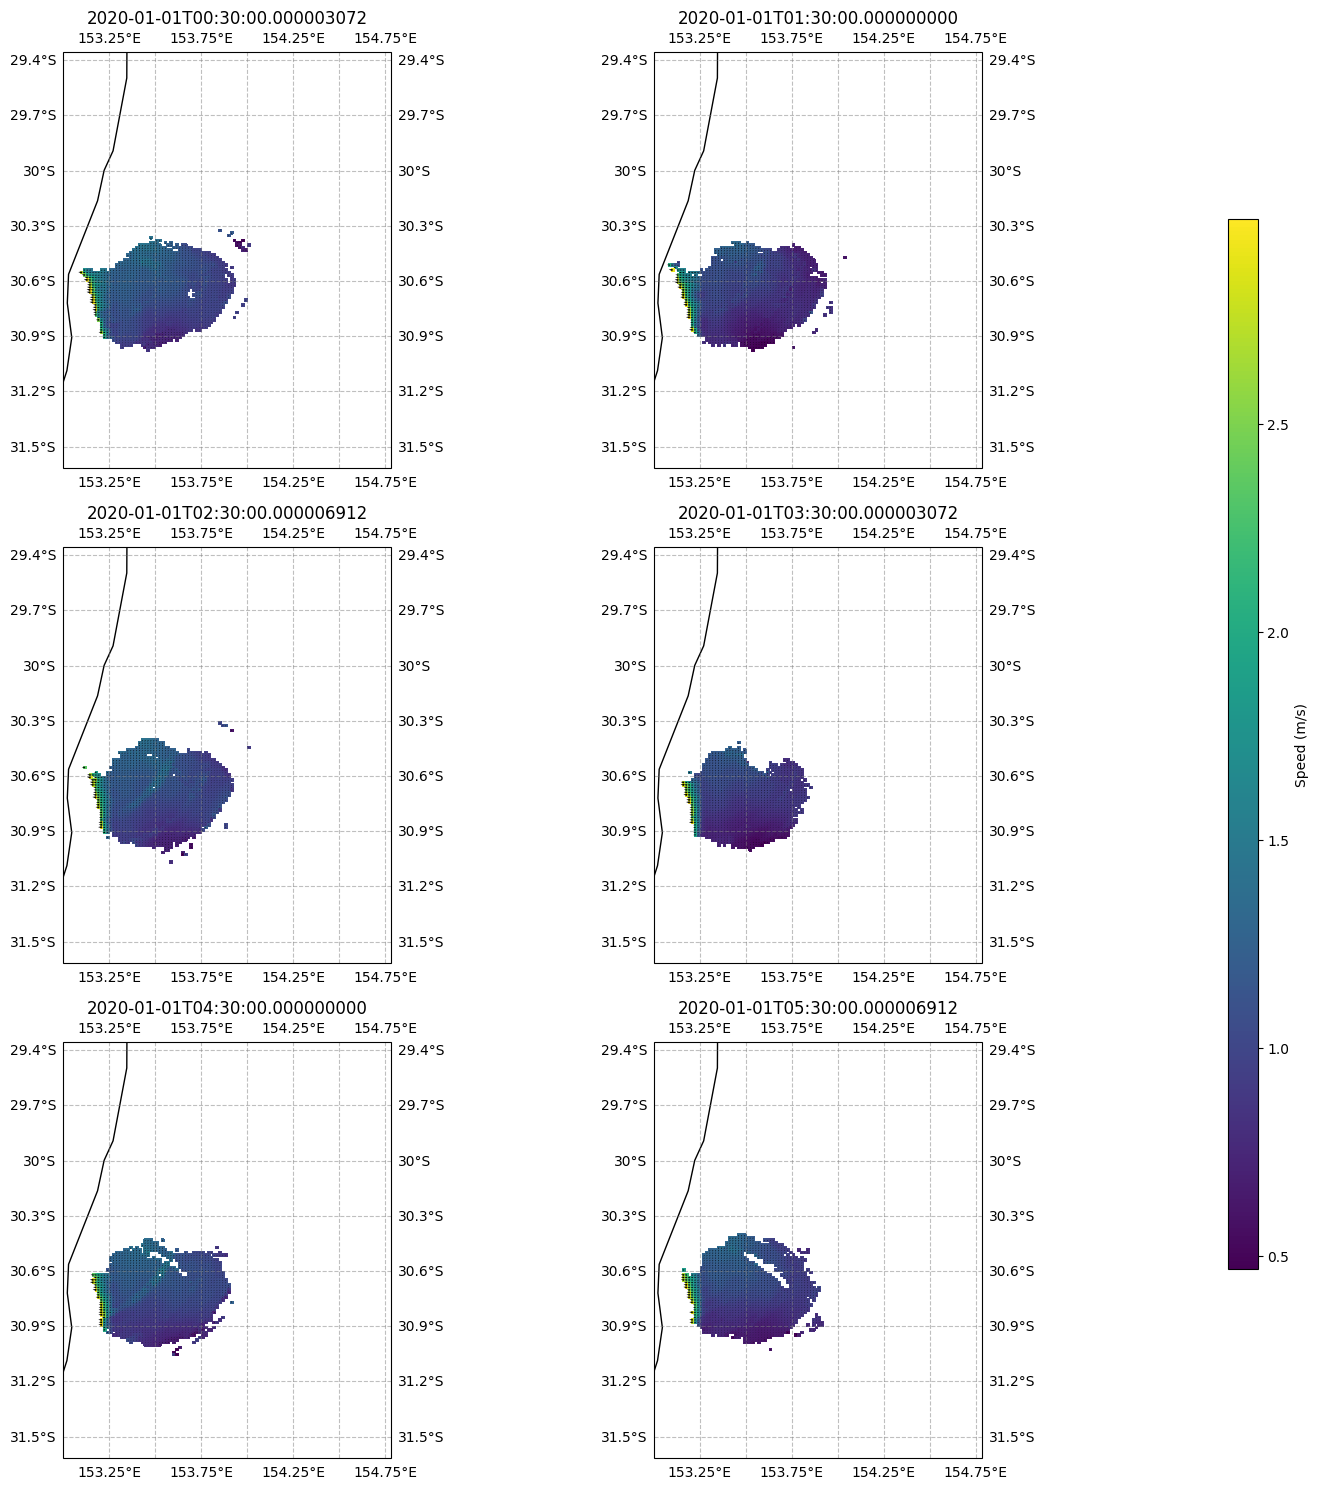

CPU times: user 14.3 s, sys: 4.28 s, total: 18.6 s
Wall time: 22.5 s


In [4]:
%%time
# 6-panel velocity snapshot — first 6 hourly records of January 2020
ds_vel.plot_radar_water_velocity_gridded(
    date_start='2020-01-01T00:00:00',
    time_name_override='TIME',
)

<Figure size 800x800 with 0 Axes>

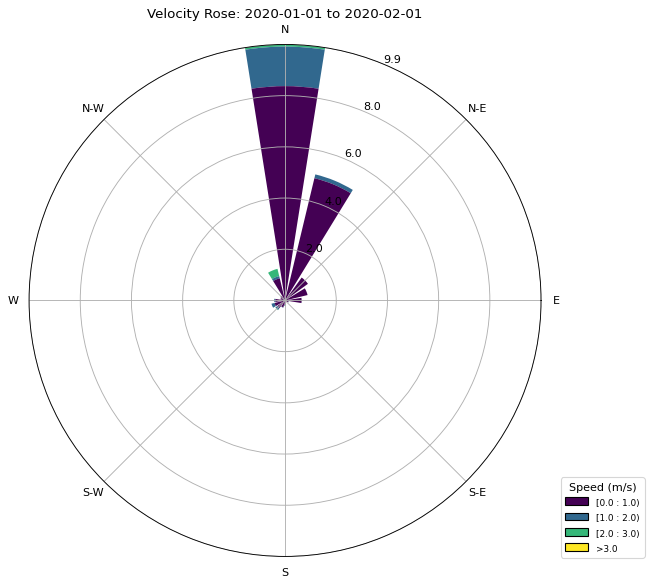

CPU times: user 940 ms, sys: 406 ms, total: 1.35 s
Wall time: 5.25 s


In [5]:
%%time
# Velocity rose — summarises dominant current directions over January 2020
ds_vel.plot_radar_water_velocity_rose(
    date_start=DATE_START,
    date_end=DATE_END,
    time_name_override='TIME',
)

In [6]:
%%time
# Find the grid point with the highest data density in January 2020
zs_vel = ds_vel.zarr_store
vel_jan = zs_vel.sel(TIME=slice(DATE_START, DATE_END))

valid_count = vel_jan['UCUR'].notnull().sum(dim='TIME').values
best_lat_i, best_lon_i = np.unravel_index(np.argmax(valid_count), valid_count.shape)
BEST_RLAT = float(zs_vel.LATITUDE.values[best_lat_i])
BEST_RLON = float(zs_vel.LONGITUDE.values[best_lon_i])
print(f"Best radar extraction point: {BEST_RLAT:.3f}°S, {BEST_RLON:.3f}°E  "
      f"({int(valid_count[best_lat_i, best_lon_i])} valid hours out of {len(vel_jan.TIME)})")

ucur_qc = vel_jan['UCUR'].where(vel_jan['UCUR_quality_control'] == 1).isel(LATITUDE=best_lat_i, LONGITUDE=best_lon_i)
vcur_qc = vel_jan['VCUR'].where(vel_jan['VCUR_quality_control'] == 1).isel(LATITUDE=best_lat_i, LONGITUDE=best_lon_i)
speed_hourly = np.sqrt(ucur_qc**2 + vcur_qc**2)
speed_daily  = speed_hourly.to_pandas().resample('D').mean()
ucur_daily   = ucur_qc.to_pandas().resample('D').mean()
vcur_daily   = vcur_qc.to_pandas().resample('D').mean()
print(f"Mean current speed: {speed_daily.mean():.3f} m s⁻¹")

Best radar extraction point: -30.811°S, 153.354°E  (665 valid hours out of 764)
Mean current speed: 0.522 m s⁻¹
CPU times: user 1.14 s, sys: 116 ms, total: 1.25 s
Wall time: 4.39 s


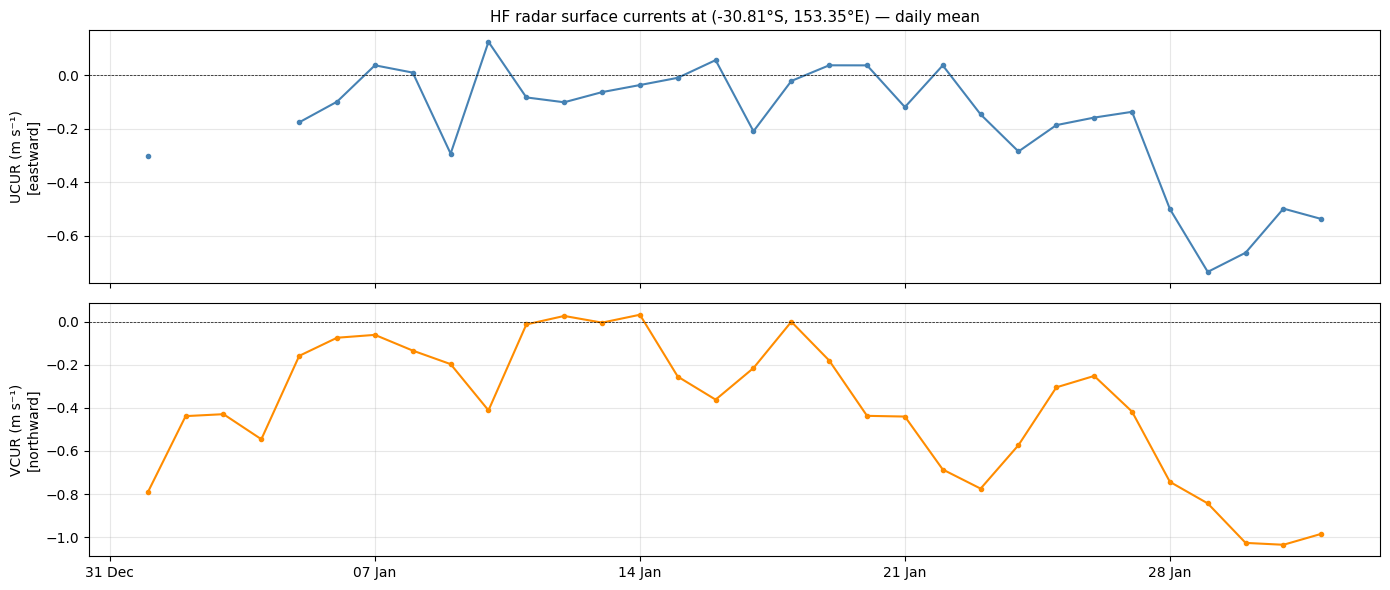

In [7]:
# U and V component timeseries at the best grid point
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(ucur_daily.index, ucur_daily.values, color='steelblue', lw=1.5, marker='o', ms=3)
axes[0].axhline(0, color='k', lw=0.5, ls='--')
axes[0].set_ylabel('UCUR (m s⁻¹)\n[eastward]')
axes[0].set_title(f'HF radar surface currents at ({BEST_RLAT:.2f}°S, {BEST_RLON:.2f}°E) — daily mean', fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(vcur_daily.index, vcur_daily.values, color='darkorange', lw=1.5, marker='o', ms=3)
axes[1].axhline(0, color='k', lw=0.5, ls='--')
axes[1].set_ylabel('VCUR (m s⁻¹)\n[northward]')
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
axes[1].xaxis.set_major_locator(mdates.WeekdayLocator())

plt.tight_layout()
plt.show()

---
## 2 · HF Radar — Wave Field

The HF radar Doppler spectrum yields wave parameters within the same footprint:
- **`VAVH`** — significant wave height (m)
- **`WPPE`** — spectral peak period (s)
- **`VDIRT`** — wave propagation direction (°)

> The wave product covers Jan 2020 (last record: Dec 2020).
> The national wave buoy archive (`wave_buoy_realtime_nonqc`) only starts Sep 2022 and cannot be used.

In [8]:
%%time
ds_wave = aodn.get_dataset('radar_CoffsHarbour_wave_delayed_qc.zarr')
ds_wave.get_temporal_extent()

CPU times: user 100 ms, sys: 1.36 ms, total: 101 ms
Wall time: 488 ms


(Timestamp('2012-03-27 23:29:59.999996928'),
 Timestamp('2020-12-11 12:30:00.000003072'))

2026-06-03 15:25:40,184 - aodn.GetAodn - INFO - Plotting 'sea_surface_wave_significant_height' for 4 time steps.


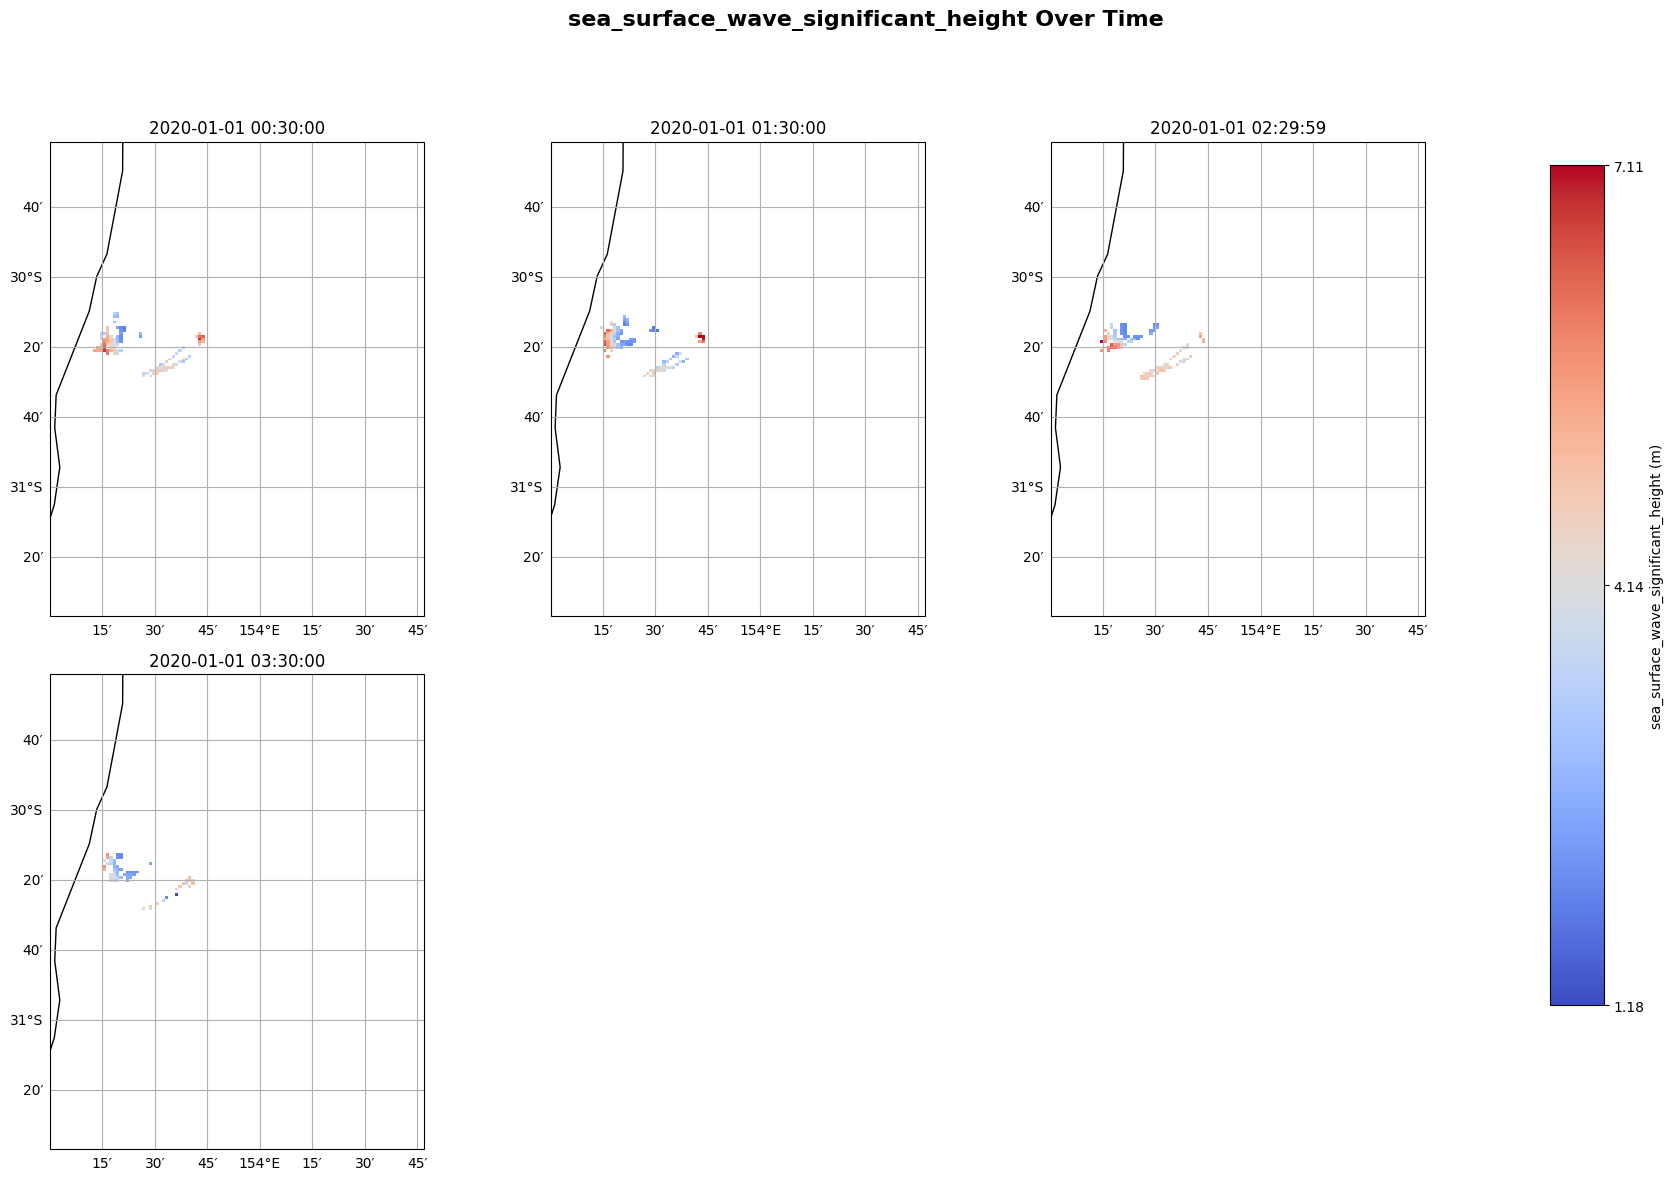

CPU times: user 2.23 s, sys: 1.42 s, total: 3.65 s
Wall time: 4.49 s


In [9]:
%%time
# Gridded significant wave height — 4 snapshots from 1 Jan 2020
ds_wave.plot_gridded_variable(
    var_name='VAVH',
    date_start=DATE_START,
    n_days=4,
    coastline_resolution='50m',
    lat_name_override='LATITUDE',
    lon_name_override='LONGITUDE',
    time_name_override='TIME',
)

In [10]:
%%time
# Find best wave extraction point (most valid VAVH data in Jan 2020)
zs_wave = ds_wave.zarr_store
wave_jan = zs_wave.sel(TIME=slice(DATE_START, DATE_END))

vavh_count = wave_jan['VAVH'].notnull().sum(dim='TIME').values
bw_lat_i, bw_lon_i = np.unravel_index(np.argmax(vavh_count), vavh_count.shape)
BEST_WLAT = float(zs_wave.LATITUDE.values[bw_lat_i])
BEST_WLON = float(zs_wave.LONGITUDE.values[bw_lon_i])
print(f"Best wave point: {BEST_WLAT:.3f}°S, {BEST_WLON:.3f}°E  "
      f"({int(vavh_count[bw_lat_i, bw_lon_i])} valid records)")

vavh_ts = wave_jan['VAVH'].where(wave_jan['VAVH_quality_control'] == 1).isel(LATITUDE=bw_lat_i, LONGITUDE=bw_lon_i)
wppe_ts = wave_jan['WPPE'].where(wave_jan['WPPE_quality_control'] == 1).isel(LATITUDE=bw_lat_i, LONGITUDE=bw_lon_i)
vavh_daily = vavh_ts.to_pandas().resample('D').mean()
wppe_daily = wppe_ts.to_pandas().resample('D').mean()
print(f"Mean VAVH: {vavh_daily.mean():.2f} m  |  Mean WPPE: {wppe_daily.mean():.1f} s")

Best wave point: -30.284°S, 153.714°E  (211 valid records)
Mean VAVH: 5.98 m  |  Mean WPPE: 9.7 s
CPU times: user 709 ms, sys: 17.5 ms, total: 726 ms
Wall time: 1.72 s


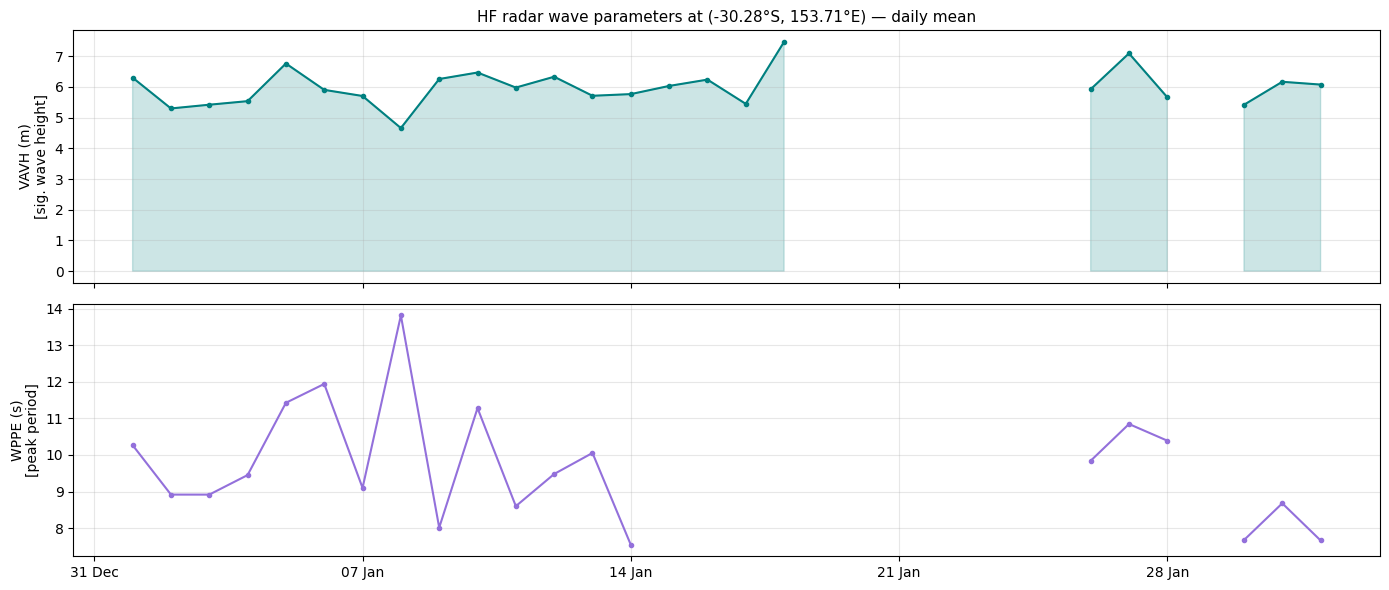

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(vavh_daily.index, vavh_daily.values, color='teal', lw=1.5, marker='o', ms=3)
axes[0].fill_between(vavh_daily.index, vavh_daily.values, alpha=0.2, color='teal')
axes[0].set_ylabel('VAVH (m)\n[sig. wave height]')
axes[0].set_title(f'HF radar wave parameters at ({BEST_WLAT:.2f}°S, {BEST_WLON:.2f}°E) — daily mean', fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(wppe_daily.index, wppe_daily.values, color='mediumpurple', lw=1.5, marker='o', ms=3)
axes[1].set_ylabel('WPPE (s)\n[peak period]')
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
axes[1].xaxis.set_major_locator(mdates.WeekdayLocator())

plt.tight_layout()
plt.show()

---
## 3 · Satellite GHRSST — Sea Surface Temperature

**GHRSST L3S multi-sensor day+night** at 0.02° daily resolution.

> **Important schema caveats (verified from live Zarr store):**
> - Coordinate names are **lowercase**: `lat`, `lon`, `time`
> - `sea_surface_temperature` is in **Kelvin** — subtract 273.15 for °C
> - `wind_speed` is listed in the JSON schema but is **absent** from the live store
> - Timeseries extraction uses `isel` with pre-computed index arrays (the `sel(time='YYYY-MM-DD')` approach fails on this store)

In [12]:
%%time
ds_sst = aodn.get_dataset('satellite_ghrsst_l3s_1day_daynighttime_multi_sensor_australia.zarr')
ds_sst.get_temporal_extent()

CPU times: user 2.08 s, sys: 323 ms, total: 2.4 s
Wall time: 3.57 s


(Timestamp('2012-01-01 09:20:00'), Timestamp('2025-11-29 09:20:00'))

2026-06-03 15:25:53,525 - aodn.GetAodn - INFO - Plotting 'sea_surface_temperature' for 4 time steps.


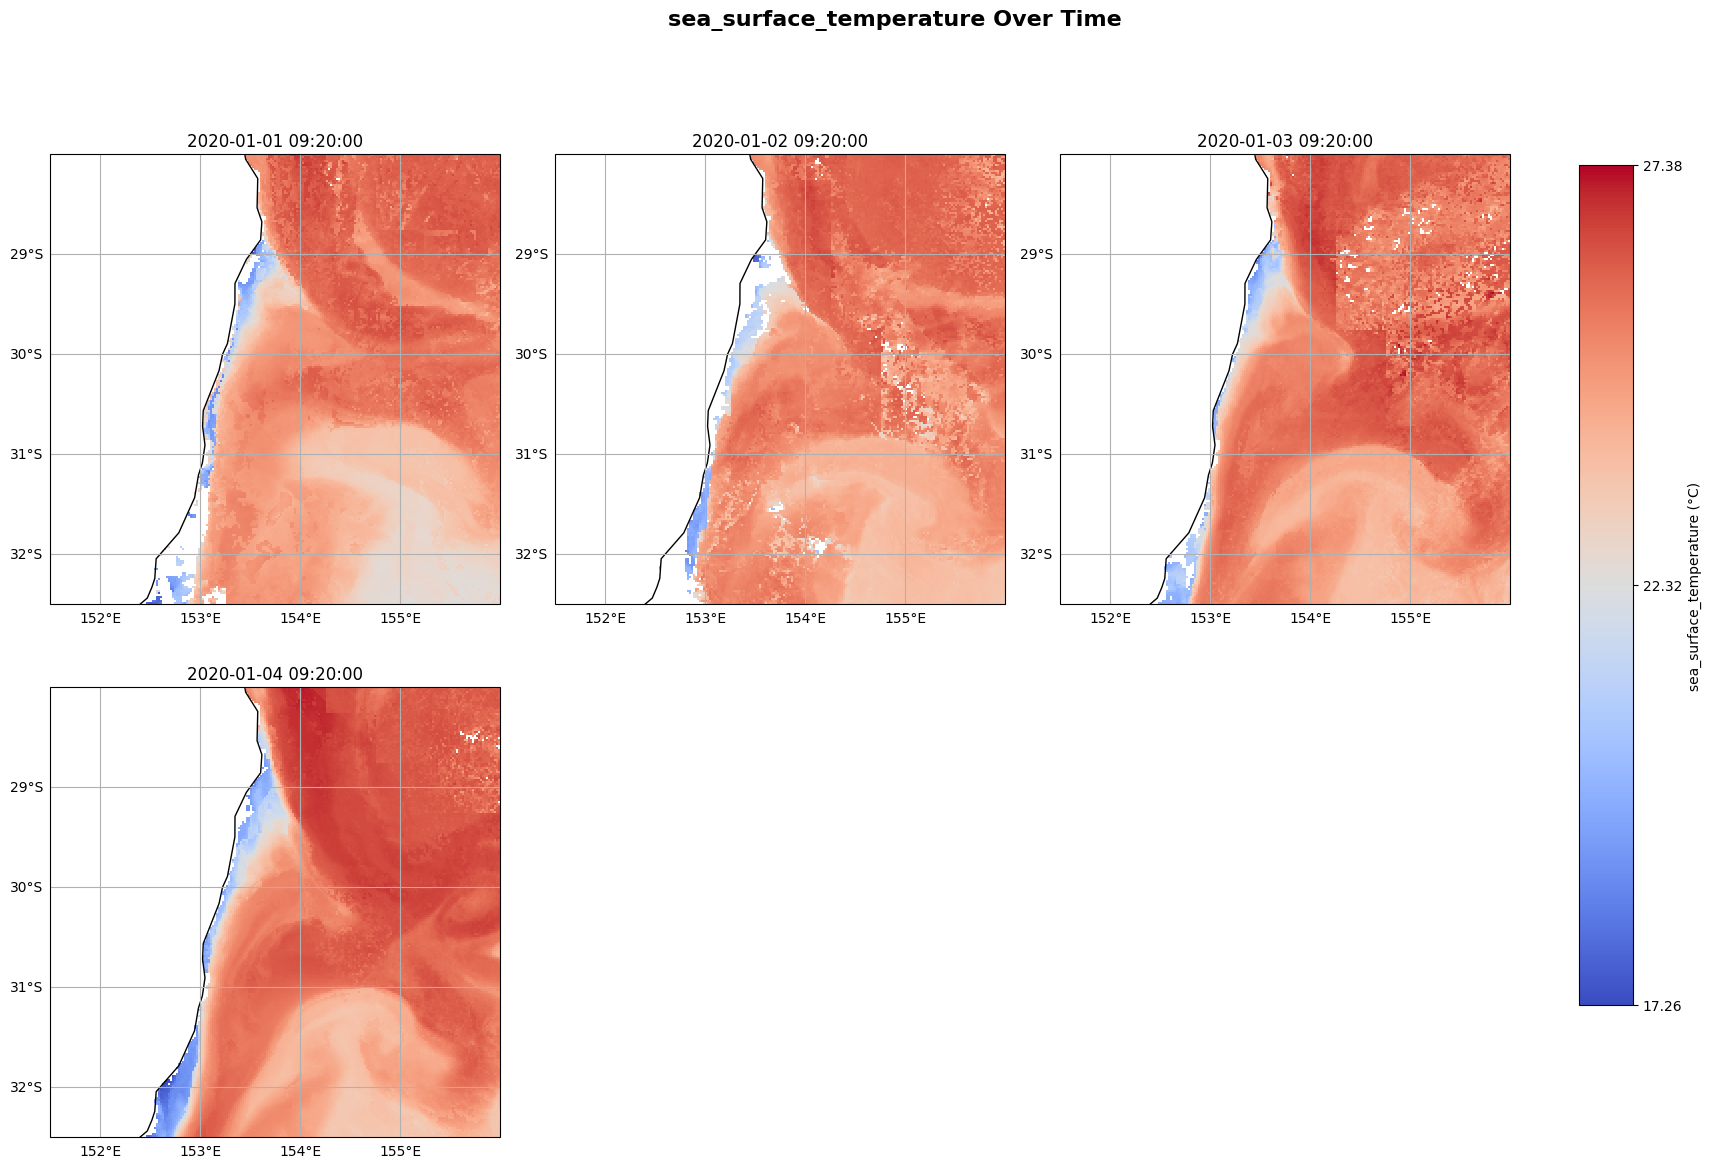

CPU times: user 10.7 s, sys: 1.86 s, total: 12.6 s
Wall time: 25.8 s


In [13]:
%%time
# Regional SST map — 4 consecutive days from 1 Jan 2020
ds_sst.plot_gridded_variable(
    var_name='sea_surface_temperature',
    date_start=DATE_START,
    n_days=4,
    lon_slice=MAP_LON,
    lat_slice=MAP_LAT,
    coastline_resolution='50m',
    log_scale=False,
)

In [14]:
%%time
# Build SST daily timeseries using isel (avoids sel/slice issues on this store)
zs_sst   = ds_sst.zarr_store
all_times = pd.to_datetime(zs_sst.time.values)
all_lats  = zs_sst.lat.values
all_lons  = zs_sst.lon.values

# Time indices for January 2020
jan_idx = np.where((all_times >= DATE_START) & (all_times < DATE_END))[0]

# Extraction point — offshore point nearest to Coffs Harbour with valid SST
SST_LAT, SST_LON = -30.5, 153.5
lat_i = int(np.argmin(np.abs(all_lats - SST_LAT)))
lon_i = int(np.argmin(np.abs(all_lons - SST_LON)))
print(f"SST extraction point: {float(all_lats[lat_i]):.3f}°S, {float(all_lons[lon_i]):.3f}°E")

sst_K = zs_sst['sea_surface_temperature'].isel(time=jan_idx, lat=lat_i, lon=lon_i).values
sst_times = all_times[jan_idx]
sst_C = sst_K - 273.15

sst_daily_C = pd.Series(sst_C, index=sst_times, name='SST_C').resample('D').mean()
print(f"Mean SST (Jan 2020): {sst_daily_C.mean():.1f} °C  |  valid days: {sst_daily_C.notna().sum()}/31")

SST extraction point: -30.490°S, 153.490°E
Mean SST (Jan 2020): 25.4 °C  |  valid days: 22/31
CPU times: user 292 ms, sys: 28.3 ms, total: 321 ms
Wall time: 3.16 s


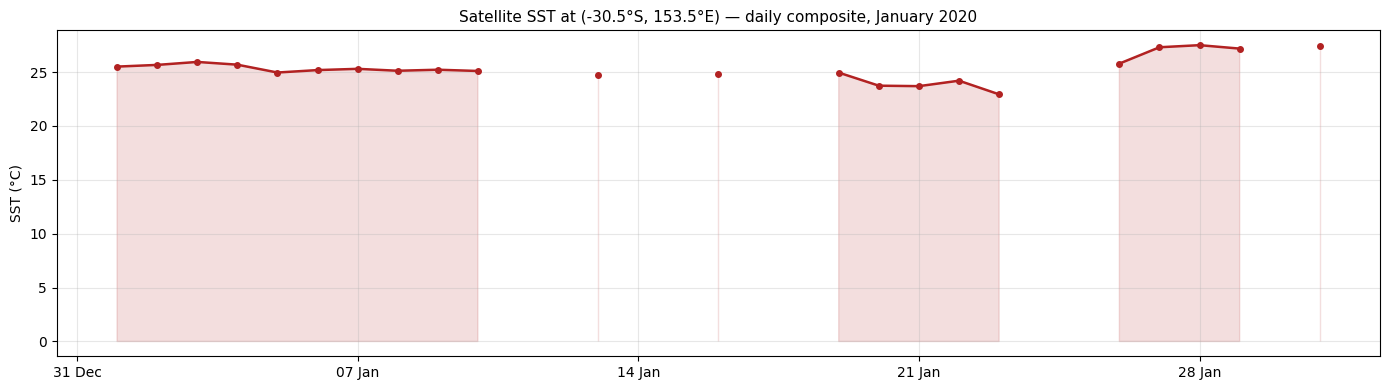

In [15]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(sst_daily_C.index, sst_daily_C.values, color='firebrick', lw=1.8, marker='o', ms=4)
ax.fill_between(sst_daily_C.index, sst_daily_C.values, alpha=0.15, color='firebrick')
ax.set_ylabel('SST (°C)')
ax.set_title(f'Satellite SST at ({SST_LAT}°S, {SST_LON}°E) — daily composite, January 2020', fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator())
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 4 · Slocum Glider — Yamba Deployment (Nov 2019)

The **Yamba20191108** deployment is the closest glider in time and space:
- Operated **7–28 November 2019** along the NSW shelf (~150 km south to north)
- Came within **15 km** of Coffs Harbour on 12 November 2019
- Provides critical subsurface context (T, S, chlorophyll to ~130 m depth) just weeks before our radar period

Variables available: `TEMP`, `PSAL`, `DEPTH`, `CPHL` (chlorophyll-a), `DOX2` (dissolved oxygen)

In [16]:
%%time
ds_glider = aodn.get_dataset('slocum_glider_delayed_qc.parquet')
# Use scalar_filter on deployment_code for efficiency
df_glider = ds_glider.get_data(
    date_start='2019-11-01',
    date_end='2019-12-01',
    scalar_filter={'deployment_code': 'Yamba20191108'},
)
print(f"Retrieved {len(df_glider):,} records from Yamba glider deployment")

2026-06-03 15:26:35,965 - aodn.GetAodn - INFO - Retrieving metadata for aodn-cloud-optimised/slocum_glider_delayed_qc.parquet


Retrieved 839,453 records from Yamba glider deployment
CPU times: user 1.99 s, sys: 1.26 s, total: 3.25 s
Wall time: 17.5 s


In [17]:
# Filter to QC-good temperature records
df_g = df_glider[
    (df_glider['TEMP_quality_control'] == 1) &
    df_glider['TEMP'].notna() &
    df_glider['DEPTH'].notna()
].copy()

# Compute distance from Coffs Harbour for each record
df_g['dist_km'] = np.sqrt(
    ((df_g['LATITUDE'] - COF_LAT) * 111) ** 2 +
    ((df_g['LONGITUDE'] - COF_LON) * 111 * np.cos(np.radians(COF_LAT))) ** 2
)
closest = df_g.loc[df_g['dist_km'].idxmin()]
print(f"Closest approach: {closest['dist_km']:.1f} km on {pd.to_datetime(closest['TIME']).strftime('%d %b %Y')}")
print(f"Track: {df_g['LATITUDE'].min():.2f}°S to {df_g['LATITUDE'].max():.2f}°S, "
      f"{df_g['LONGITUDE'].min():.2f}°E to {df_g['LONGITUDE'].max():.2f}°E")
print(f"Depth range: {df_g['DEPTH'].min():.0f} to {df_g['DEPTH'].max():.0f} m")

Closest approach: 15.1 km on 12 Nov 2019
Track: -32.75°S to -29.49°S, 152.29°E to 153.57°E
Depth range: -0 to 133 m


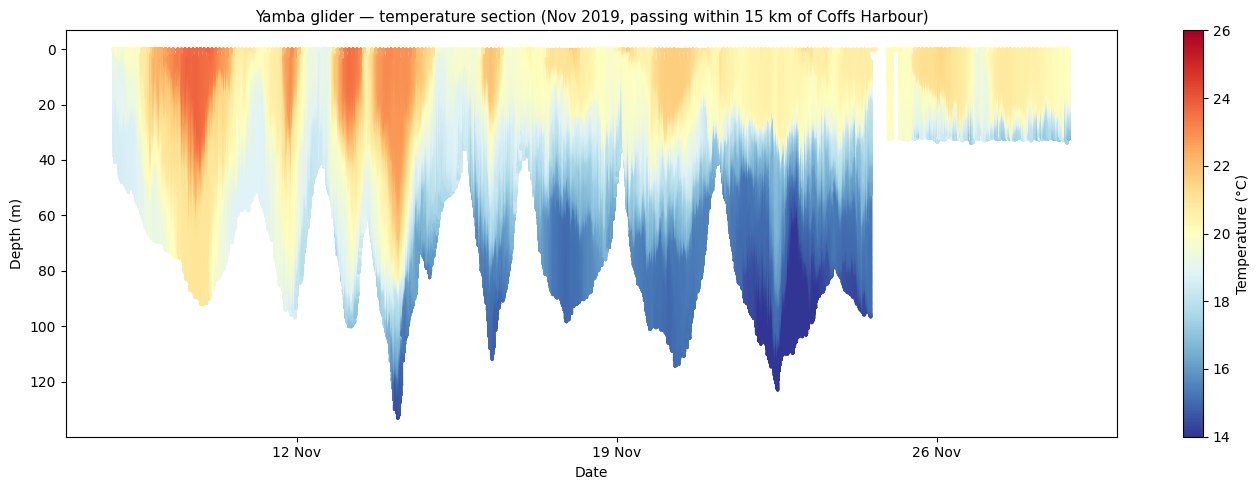

In [18]:
# Depth–time temperature section (colour = temperature)
fig, ax = plt.subplots(figsize=(14, 5))
sc = ax.scatter(
    pd.to_datetime(df_g['TIME']), df_g['DEPTH'],
    c=df_g['TEMP'], cmap='RdYlBu_r', s=1.5, vmin=14, vmax=26,
)
plt.colorbar(sc, ax=ax, label='Temperature (°C)')
ax.invert_yaxis()
ax.set_xlabel('Date')
ax.set_ylabel('Depth (m)')
ax.set_title('Yamba glider — temperature section (Nov 2019, passing within 15 km of Coffs Harbour)', fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator())
plt.tight_layout()
plt.show()

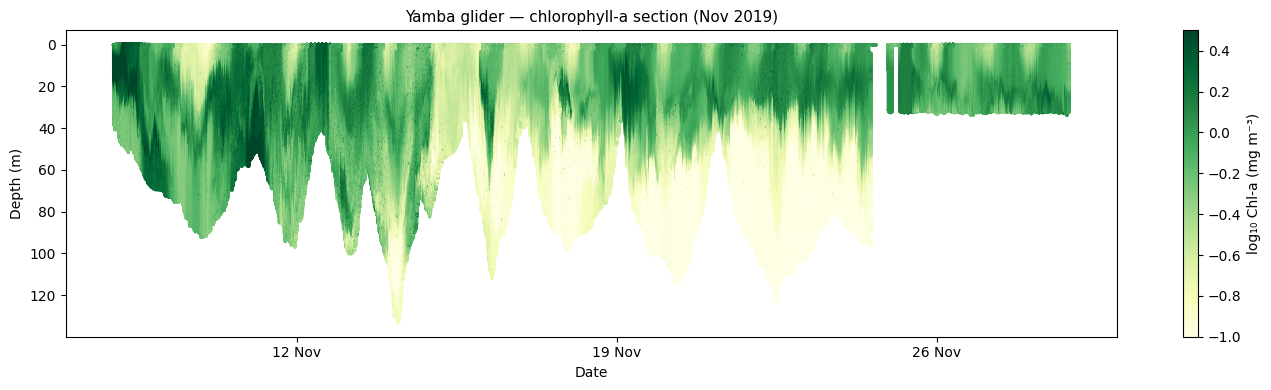

In [19]:
# Chlorophyll-a section (if available)
df_cphl = df_g[df_g['CPHL'].notna()]
if not df_cphl.empty:
    fig, ax = plt.subplots(figsize=(14, 4))
    sc = ax.scatter(
        pd.to_datetime(df_cphl['TIME']), df_cphl['DEPTH'],
        c=np.log10(df_cphl['CPHL'].clip(lower=0.01)), cmap='YlGn', s=1.5, vmin=-1, vmax=0.5,
    )
    cbar = plt.colorbar(sc, ax=ax, label='log₁₀ Chl-a (mg m⁻³)')
    ax.invert_yaxis()
    ax.set_xlabel('Date')
    ax.set_ylabel('Depth (m)')
    ax.set_title('Yamba glider — chlorophyll-a section (Nov 2019)', fontsize=11)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator())
    plt.tight_layout()
    plt.show()

T-S records: 834,116


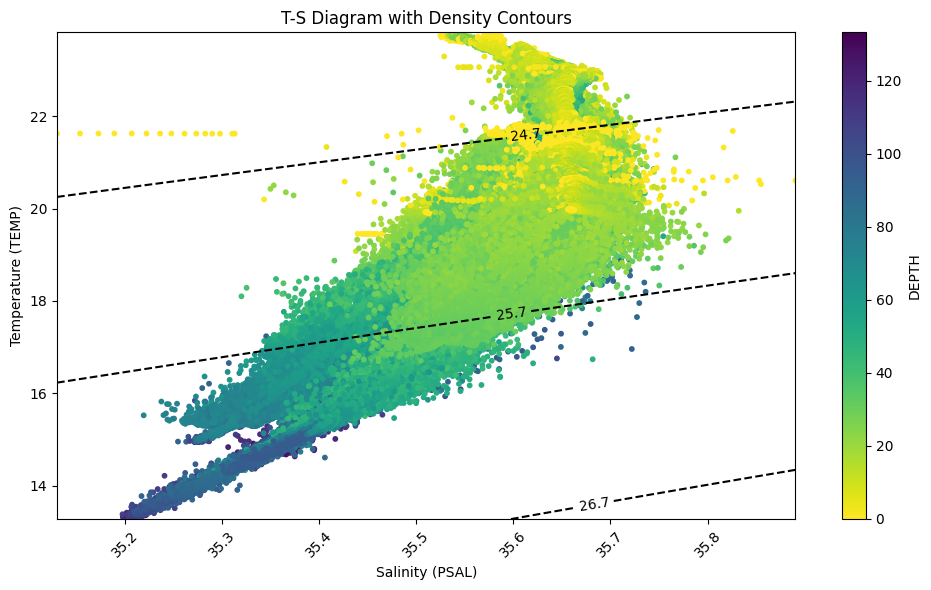

In [20]:
# T-S diagram for the glider (use only 3 columns to avoid duplicate-label issue in plot_ts_diagram)
df_g_ts = df_glider[
    (df_glider['TEMP_quality_control'] == 1) &
    (df_glider['PSAL_quality_control'] == 1) &
    df_glider['TEMP'].notna() &
    df_glider['PSAL'].notna() &
    df_glider['DEPTH'].notna()
][['TEMP', 'PSAL', 'DEPTH']].reset_index(drop=True)

print(f"T-S records: {len(df_g_ts):,}")
plot_ts_diagram(df_g_ts, temp_col='TEMP', psal_col='PSAL', z_col='DEPTH')

---
## 5 · Argo Floats — Subsurface Profiles

We query all Argo core profiles within ±5° of Coffs Harbour for **Dec 2019 – Feb 2020**
and rank floats by closest approach to the reference point.

> **Argo schema notes (confirmed from live store):**
> - Time column: **`JULD`** (datetime64[ns])
> - QC flags are **strings**: filter with `TEMP_QC == '1'`
> - Argo already has `TEMP`, `PSAL`, `PRES` columns; use those directly with `plot_ts_diagram`

In [21]:
%%time
ds_argo = aodn.get_dataset('argo.parquet')
df_argo = ds_argo.get_data(
    date_start='2019-12-01',
    date_end='2020-02-28',
    lat_min=LAT_MIN, lat_max=LAT_MAX,
    lon_min=LON_MIN, lon_max=LON_MAX,
)
print(f"Retrieved {len(df_argo):,} Argo records")

2026-06-03 15:27:46,851 - aodn.GetAodn - INFO - Retrieving metadata for aodn-cloud-optimised/argo.parquet


Retrieved 52,495 Argo records
CPU times: user 4.07 s, sys: 512 ms, total: 4.58 s
Wall time: 32.1 s


In [22]:
# Rank floats by closest approach to Coffs Harbour
min_dist_per_float = (
    df_argo.dropna(subset=['LATITUDE', 'LONGITUDE'])
    .assign(dist_km=lambda d: np.sqrt(
        ((d['LATITUDE'] - COF_LAT) * 111) ** 2 +
        ((d['LONGITUDE'] - COF_LON) * 111 * np.cos(np.radians(COF_LAT))) ** 2
    ))
    .groupby('PLATFORM_NUMBER')
    .agg(
        closest_km=('dist_km', 'min'),
        n_cycles=('CYCLE_NUMBER', 'nunique'),
        lat_mean=('LATITUDE', 'mean'),
        lon_mean=('LONGITUDE', 'mean'),
        t_first=('JULD', 'min'),
        t_last=('JULD', 'max'),
    )
    .reset_index()
    .sort_values('closest_km')
)
print(min_dist_per_float[['PLATFORM_NUMBER','closest_km','n_cycles','lat_mean','lon_mean','t_first','t_last']].to_string(index=False))

 PLATFORM_NUMBER  closest_km  n_cycles   lat_mean   lon_mean                       t_first                        t_last
         5905440   65.009614         7 -32.832600 152.657243 2019-12-04 14:51:26.000000000 2020-02-22 14:48:56.000000000
         5905410  197.036327         8 -32.716156 153.991629 2019-12-10 05:22:10.999999744 2020-02-18 06:25:48.000000000
         5905441  239.043455         8 -31.636125 155.746000 2019-12-10 21:40:57.000000000 2020-02-19 05:45:03.000000000
         5905442  257.039390         8 -31.384375 156.620375 2019-12-10 21:51:27.999999744 2020-02-19 01:04:15.000000000
         5905437  327.744836         8 -27.500787 154.865525 2019-12-19 07:21:53.999999744 2020-02-27 07:22:53.000000256
         5905439  340.741991         9 -28.766356 156.487378 2019-12-01 18:03:15.000000000 2020-02-19 17:20:50.000000000
         5903622  442.977020         2 -28.392500 157.273500 2019-12-02 20:17:22.000000000 2019-12-12 22:54:38.000000000
         5905438  448.681084    

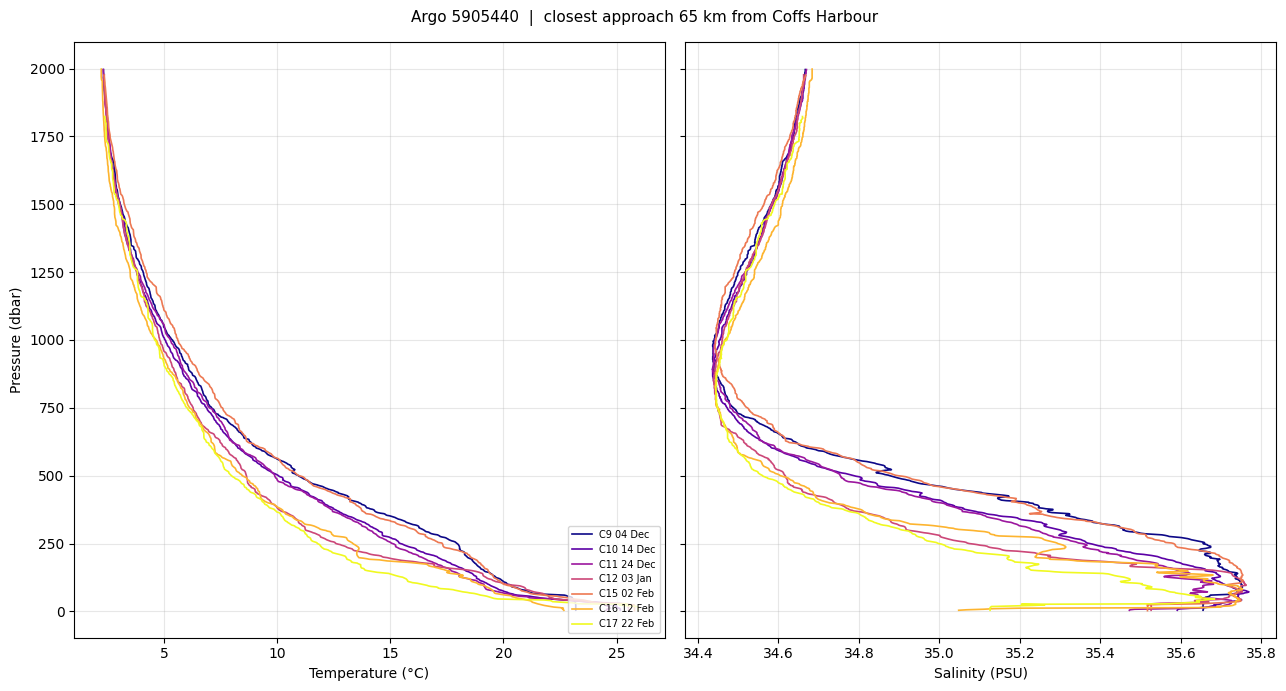

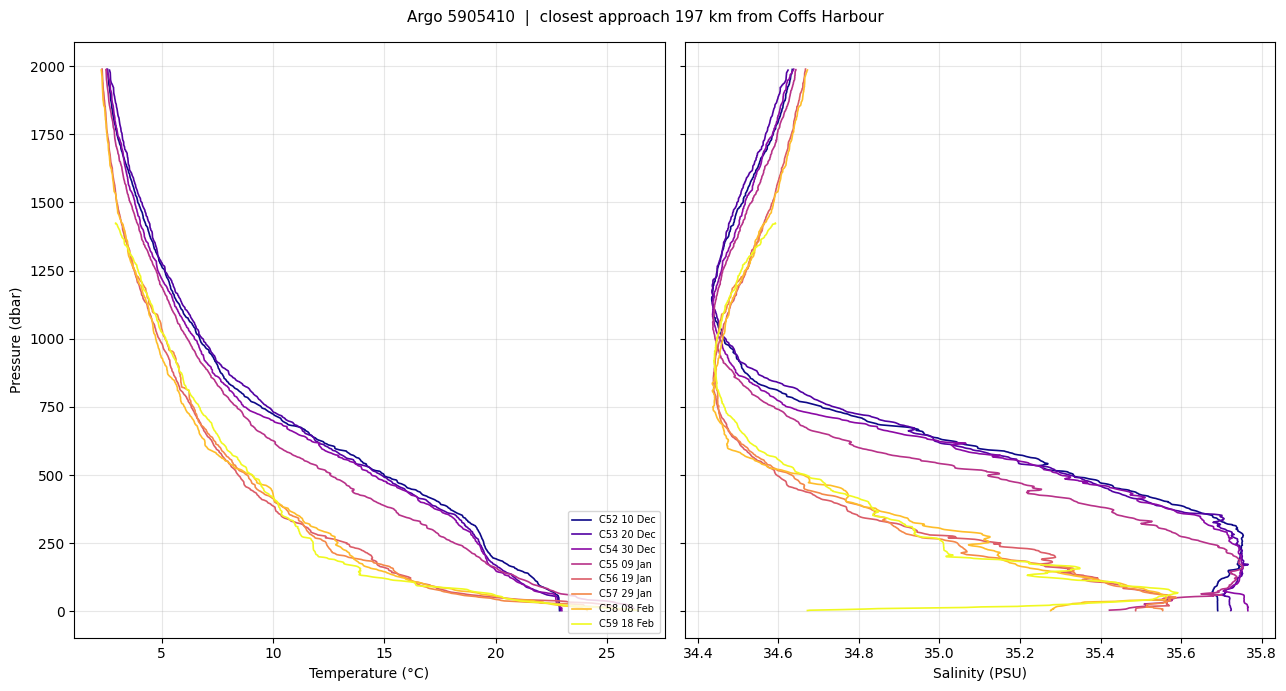

In [23]:
# Plot vertical T and S profiles for the two closest floats
for platform in min_dist_per_float.head(2)['PLATFORM_NUMBER'].tolist():
    sub = df_argo[df_argo['PLATFORM_NUMBER'] == platform].copy()

    # Use raw TEMP/PSAL/PRES (QC string flags)
    sub_good = sub[
        (sub['TEMP_QC'] == '1') &
        sub['TEMP'].notna() &
        sub['PRES'].notna()
    ]
    if sub_good.empty:
        print(f"No valid data for float {platform}")
        continue

    cycles = sorted(sub_good['CYCLE_NUMBER'].unique())
    cmap   = plt.cm.plasma
    colors = {c: cmap(i / max(len(cycles) - 1, 1)) for i, c in enumerate(cycles)}

    fig, axes = plt.subplots(1, 2, figsize=(13, 7), sharey=True)
    for cycle in cycles:
        cdf = sub_good[sub_good['CYCLE_NUMBER'] == cycle].sort_values('PRES')
        col = colors[cycle]
        lbl = f"C{int(cycle)} {pd.to_datetime(cdf['JULD'].iloc[0]).strftime('%d %b')}"
        axes[0].plot(cdf['TEMP'], cdf['PRES'], color=col, lw=1.2, label=lbl)
        psal_ok = cdf[cdf['PSAL_QC'] == '1']
        if not psal_ok.empty:
            axes[1].plot(psal_ok['PSAL'], psal_ok['PRES'], color=col, lw=1.2)

    for ax in axes:
        ax.invert_yaxis()
        ax.grid(True, alpha=0.3)
    axes[0].set_xlabel('Temperature (°C)')
    axes[0].set_ylabel('Pressure (dbar)')
    axes[1].set_xlabel('Salinity (PSU)')
    handles, labels = axes[0].get_legend_handles_labels()
    axes[0].legend(handles[:10], labels[:10], fontsize=7, loc='lower right')

    row = min_dist_per_float[min_dist_per_float['PLATFORM_NUMBER'] == platform].iloc[0]
    fig.suptitle(
        f"Argo {platform}  |  closest approach {row['closest_km']:.0f} km from Coffs Harbour",
        fontsize=11,
    )
    plt.tight_layout()
    plt.show()

T-S records: 51,175


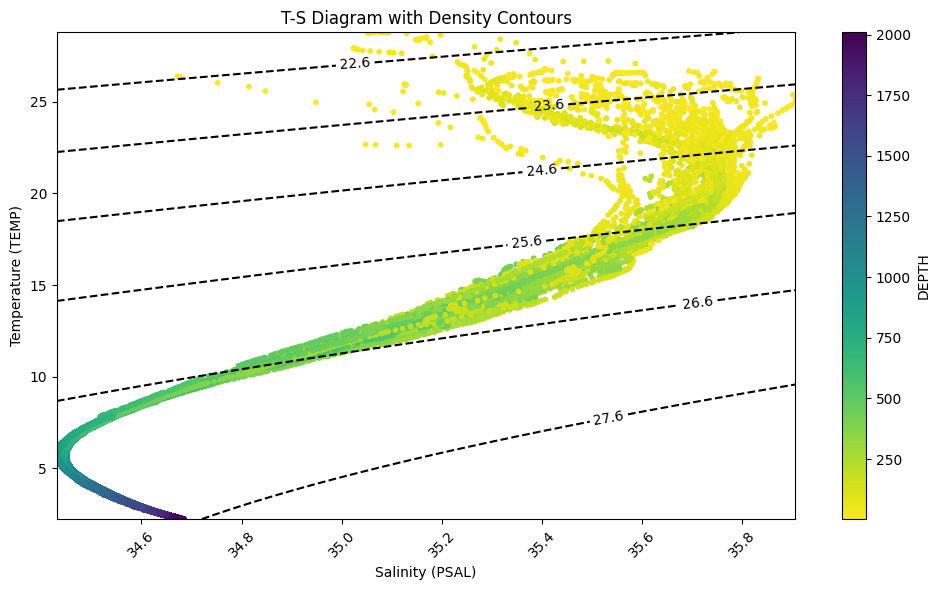

In [24]:
# T-S diagram for all Argo profiles in the region
# Use only TEMP/PSAL/PRES columns to avoid duplicate-label issue in plot_ts_diagram
df_argo_ts = df_argo[
    (df_argo['TEMP_QC'] == '1') &
    (df_argo['PSAL_QC'] == '1') &
    df_argo['TEMP'].notna() &
    df_argo['PSAL'].notna() &
    df_argo['PRES'].notna()
][['TEMP', 'PSAL', 'PRES']].rename(columns={'PRES': 'DEPTH'}).reset_index(drop=True)

print(f"T-S records: {len(df_argo_ts):,}")
plot_ts_diagram(df_argo_ts, temp_col='TEMP', psal_col='PSAL', z_col='DEPTH')

---
## 6 · Integrated Sea State Overview

### 6a · 4-panel daily time-series

All surface variables on a shared time axis.

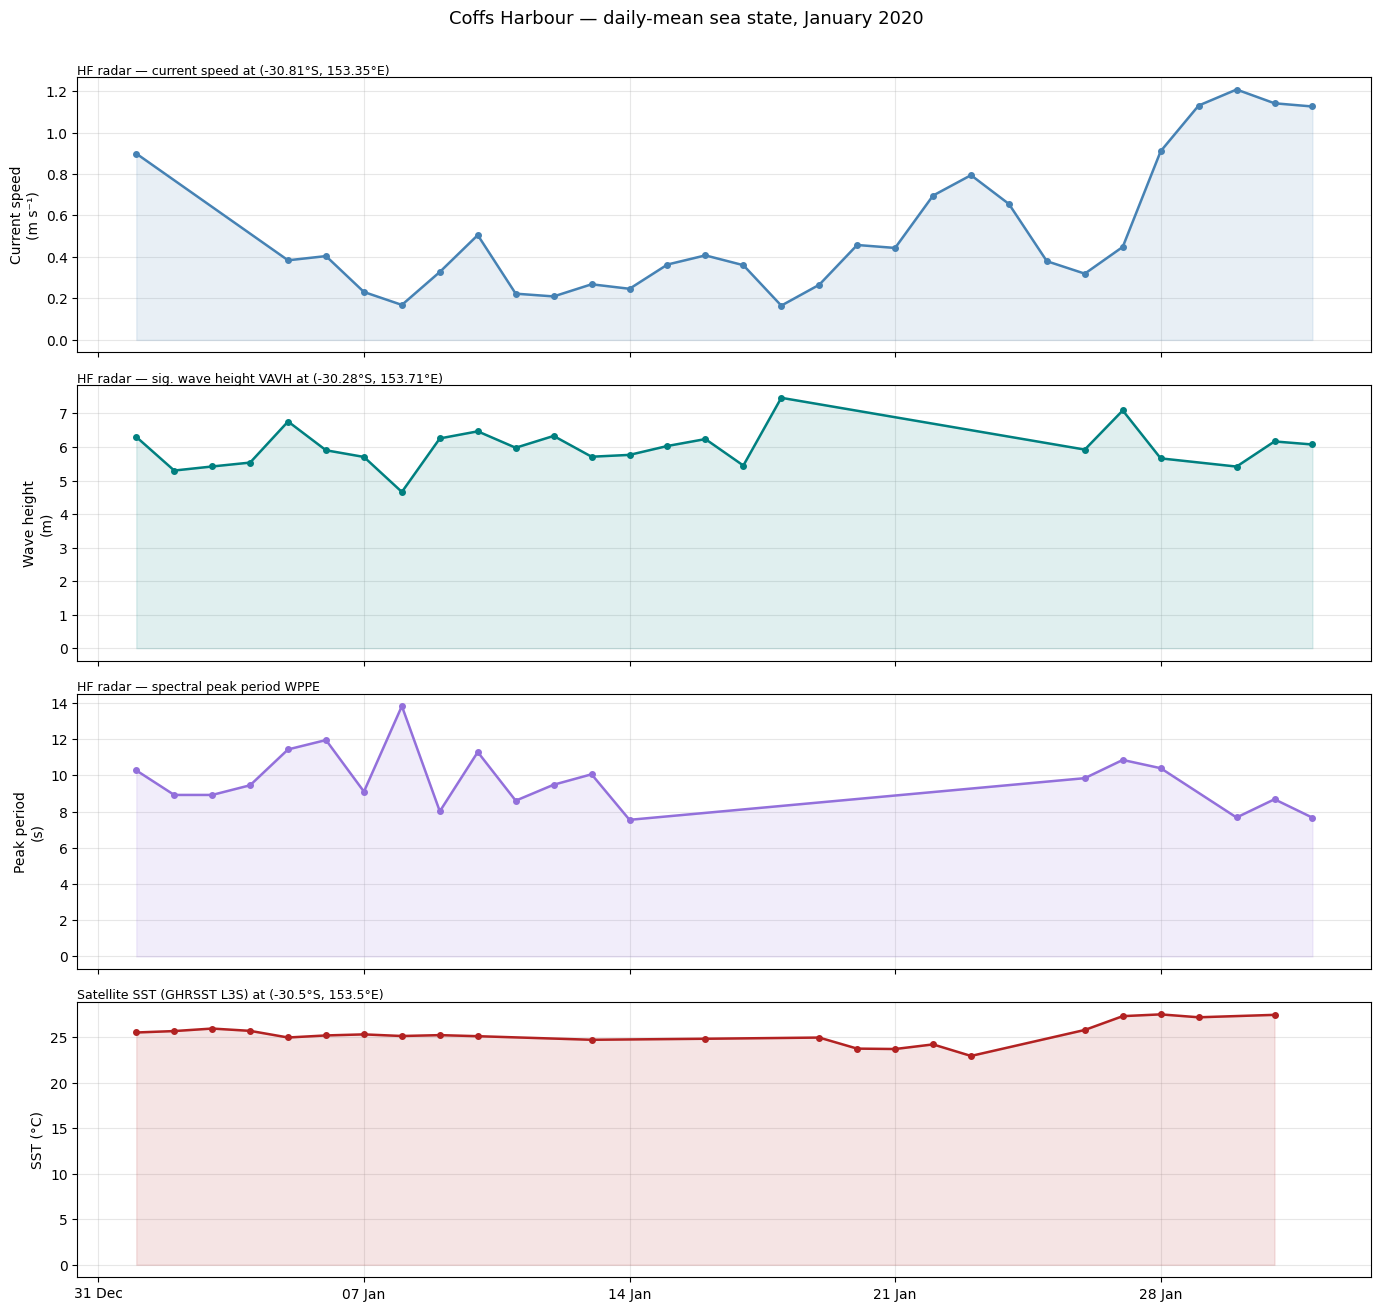

In [25]:
fig, axes = plt.subplots(4, 1, figsize=(14, 13), sharex=True)

panels = [
    (speed_daily,   'Current speed\n(m s⁻¹)',  'steelblue',    f'HF radar — current speed at ({BEST_RLAT:.2f}°S, {BEST_RLON:.2f}°E)'),
    (vavh_daily,    'Wave height\n(m)',          'teal',         f'HF radar — sig. wave height VAVH at ({BEST_WLAT:.2f}°S, {BEST_WLON:.2f}°E)'),
    (wppe_daily,    'Peak period\n(s)',          'mediumpurple', f'HF radar — spectral peak period WPPE'),
    (sst_daily_C,   'SST (°C)',                  'firebrick',    f'Satellite SST (GHRSST L3S) at ({SST_LAT}°S, {SST_LON}°E)'),
]

for ax, (series, ylabel, color, title) in zip(axes, panels):
    valid = series.dropna()
    ax.plot(valid.index, valid.values, color=color, lw=1.8, marker='o', ms=4, zorder=3)
    ax.fill_between(valid.index, valid.values, alpha=0.12, color=color, zorder=2)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=9, loc='left', pad=2)
    ax.grid(True, alpha=0.3, zorder=1)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
axes[-1].xaxis.set_major_locator(mdates.WeekdayLocator())

fig.suptitle('Coffs Harbour — daily-mean sea state, January 2020', fontsize=13, y=1.005)
plt.tight_layout()
plt.show()

### 6b · Platform location map

All datasets overlaid on the mean satellite SST for January 2020.

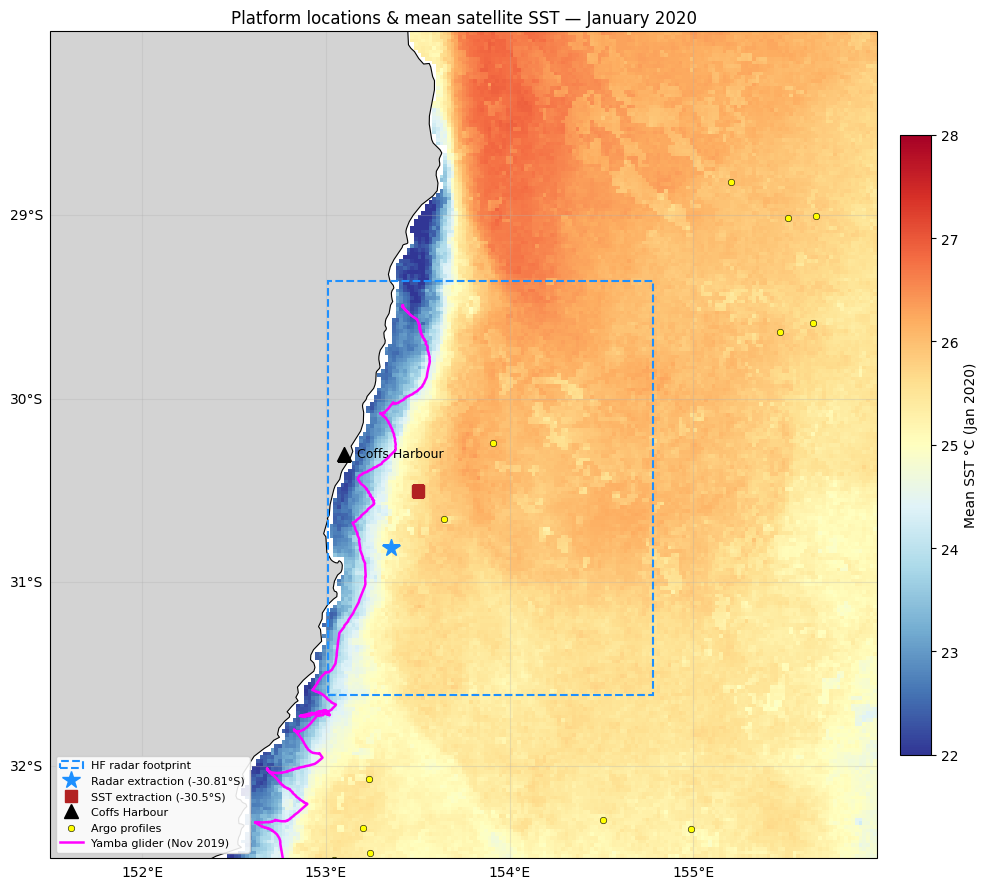

In [26]:
# Compute mean SST for January 2020 over the map region
lat_idx_map = np.where((all_lats >= MAP_LAT[0]) & (all_lats <= MAP_LAT[1]))[0]
lon_idx_map = np.where((all_lons >= MAP_LON[0]) & (all_lons <= MAP_LON[1]))[0]

sst_mean_K = zs_sst['sea_surface_temperature'].isel(
    time=jan_idx,
    lat=slice(lat_idx_map[0], lat_idx_map[-1]+1),
    lon=slice(lon_idx_map[0], lon_idx_map[-1]+1),
).mean(dim='time')
sst_mean_C = sst_mean_K - 273.15
lons_map = all_lons[lon_idx_map[0]:lon_idx_map[-1]+1]
lats_map = all_lats[lat_idx_map[0]:lat_idx_map[-1]+1]

fig = plt.figure(figsize=(12, 9))
ax  = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([MAP_LON[0], MAP_LON[1], MAP_LAT[0], MAP_LAT[1]])

# Mean SST background
pcm = ax.pcolormesh(
    lons_map, lats_map, sst_mean_C.values,
    cmap='RdYlBu_r', vmin=22, vmax=28,
    transform=ccrs.PlateCarree(), zorder=1,
)
plt.colorbar(pcm, ax=ax, label='Mean SST °C (Jan 2020)', shrink=0.75, pad=0.02)

ax.add_feature(cfeature.LAND,      facecolor='lightgrey', zorder=2)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8,          zorder=3)
gl = ax.gridlines(draw_labels=True, alpha=0.3, zorder=3)
gl.top_labels = False; gl.right_labels = False

# HF radar domain (approximate bounding box from live store)
ax.add_patch(Rectangle(
    (153.01, -31.61), 154.78 - 153.01, -29.36 - (-31.61),
    linewidth=1.5, edgecolor='dodgerblue', facecolor='none', linestyle='--',
    transform=ccrs.PlateCarree(), zorder=4, label='HF radar footprint',
))

# Extraction points
ax.plot(BEST_RLON, BEST_RLAT, '*', ms=13, color='dodgerblue',
        transform=ccrs.PlateCarree(), zorder=5, label=f'Radar extraction ({BEST_RLAT:.2f}°S)')
ax.plot(SST_LON, SST_LAT, 's', ms=8, color='firebrick',
        transform=ccrs.PlateCarree(), zorder=5, label=f'SST extraction ({SST_LAT}°S)')

# Coffs Harbour
ax.plot(COF_LON, COF_LAT, '^k', ms=10,
        transform=ccrs.PlateCarree(), zorder=5, label='Coffs Harbour')
ax.text(COF_LON + 0.07, COF_LAT, 'Coffs Harbour',
        transform=ccrs.PlateCarree(), fontsize=9, va='center', zorder=6)

# Argo float mean positions
argo_locs = (
    df_argo.dropna(subset=['LATITUDE','LONGITUDE'])
    .drop_duplicates(subset=['PLATFORM_NUMBER','CYCLE_NUMBER'])
)
ax.scatter(
    argo_locs['LONGITUDE'], argo_locs['LATITUDE'],
    s=22, c='yellow', edgecolors='k', linewidths=0.4,
    transform=ccrs.PlateCarree(), zorder=6, label='Argo profiles',
)

# Glider track (Yamba)
ax.plot(
    df_g.sort_values('TIME')['LONGITUDE'],
    df_g.sort_values('TIME')['LATITUDE'],
    color='magenta', lw=1.8, zorder=6,
    transform=ccrs.PlateCarree(), label='Yamba glider (Nov 2019)',
)

ax.legend(loc='lower left', fontsize=8, framealpha=0.88)
ax.set_title('Platform locations & mean satellite SST — January 2020', fontsize=12)
plt.tight_layout()
plt.show()

### 6c · Cross-variable scatter analysis

Pearson correlations between daily-mean surface variables.

Days with all four variables valid: 12

Pearson correlations:
                  current_speed_ms  wave_height_m  peak_period_s  sst_C
current_speed_ms              1.00           0.24          -0.31   0.69
wave_height_m                 0.24           1.00          -0.33   0.23
peak_period_s                -0.31          -0.33           1.00  -0.25
sst_C                         0.69           0.23          -0.25   1.00


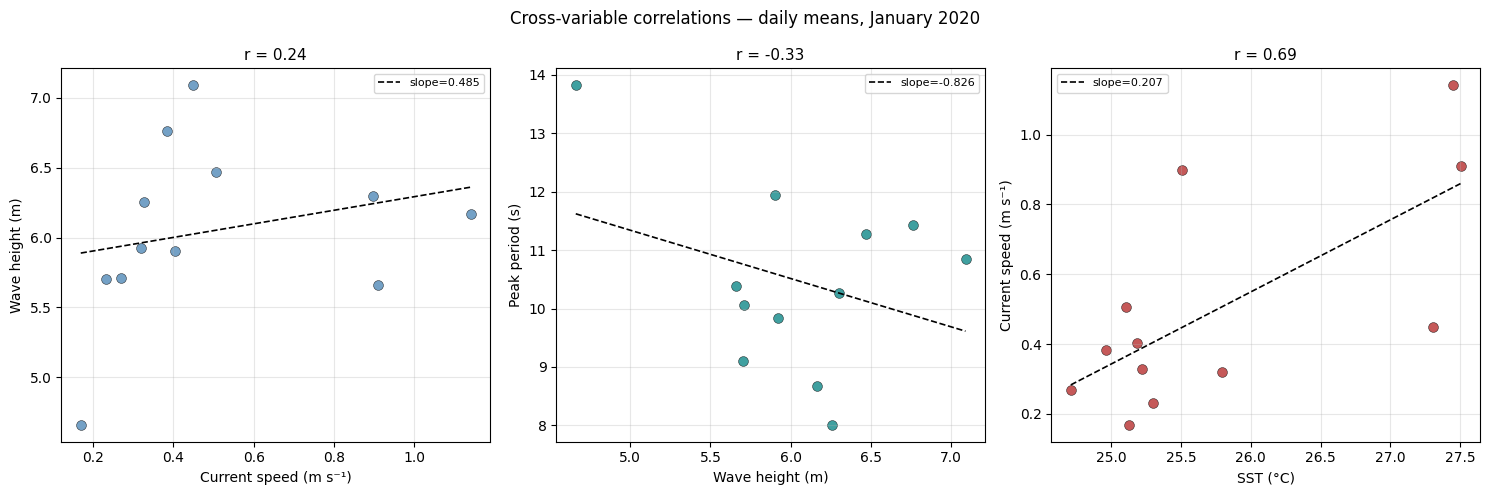

In [27]:
df_combined = pd.DataFrame({
    'current_speed_ms': speed_daily,
    'wave_height_m':    vavh_daily,
    'peak_period_s':    wppe_daily,
    'sst_C':            sst_daily_C,
}).dropna()

print(f"Days with all four variables valid: {len(df_combined)}")
print("\nPearson correlations:")
print(df_combined.corr().round(2).to_string())

pairs = [
    ('current_speed_ms', 'wave_height_m',  'Current speed (m s⁻¹)', 'Wave height (m)',  'steelblue'),
    ('wave_height_m',    'peak_period_s',  'Wave height (m)',        'Peak period (s)',  'teal'),
    ('sst_C',            'current_speed_ms','SST (°C)',              'Current speed (m s⁻¹)', 'firebrick'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (x, y, xl, yl, col) in zip(axes, pairs):
    xy = df_combined[[x, y]].dropna()
    ax.scatter(xy[x], xy[y], c=col, s=50, alpha=0.75, edgecolors='k', lw=0.4)
    if len(xy) >= 3:
        m, b = np.polyfit(xy[x], xy[y], 1)
        xs   = np.linspace(xy[x].min(), xy[x].max(), 50)
        ax.plot(xs, m*xs+b, 'k--', lw=1.2, label=f'slope={m:.3f}')
    r = xy.corr().iloc[0, 1]
    ax.set_title(f'r = {r:.2f}', fontsize=11)
    ax.set_xlabel(xl); ax.set_ylabel(yl)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

fig.suptitle('Cross-variable correlations — daily means, January 2020', fontsize=12)
plt.tight_layout()
plt.show()